# Adversarial Natural Language Inference

## Installing the Required Libraries

In [1]:
!pip install -q num2words

## Importing the Required Libraries

In [2]:
import nltk
import torch
from transformers import (
    set_seed,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)
import os

from datasets import (
    load_dataset,
    Dataset,
    DatasetDict,
    load_metric,
    concatenate_datasets
)
from collections import Counter
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import numpy as np

from nltk.corpus import wordnet as wn

import random

from num2words import num2words

2024-07-11 09:22:58.032599: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-11 09:22:58.032715: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-11 09:22:58.158264: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Settings

In [3]:
nltk.download('wordnet')
!unzip /usr/share/nltk_data/corpora/wordnet.zip -d /usr/share/nltk_data/corpora/

language_model_name = "roberta-base"
batch_size = 16
learning_rate = 1e-4
weight_decay = 0.001
epochs = 1
device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(42)

os.environ["WANDB_API_KEY"] = "5256cdfe41cf4c71f566795003c22d825f739f89"

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Archive:  /usr/share/nltk_data/corpora/wordnet.zip
   creating: /usr/share/nltk_data/corpora/wordnet/
  inflating: /usr/share/nltk_data/corpora/wordnet/lexnames  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.verb  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.adv  
  inflating: /usr/share/nltk_data/corpora/wordnet/adv.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.verb  
  inflating: /usr/share/nltk_data/corpora/wordnet/cntlist.rev  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.adj  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.adj  
  inflating: /usr/share/nltk_data/corpora/wordnet/LICENSE  
  inflating: /usr/share/nltk_data/corpora/wordnet/citation.bib  
  inflating: /usr/share/nltk_data/corpora/wordnet/noun.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/verb.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/README  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.sense  
  inflating: /usr/share/nltk_data

## Hyperparameters

## Helper Functions

### Drawing the Distribution

In [4]:
def draw_dist(labels):
    label_counts = Counter(labels)
    sorted_label_counts = sorted(label_counts.items())
    labels, counts = zip(*sorted_label_counts)

    plt.figure(figsize=(10, 6))
    plt.bar(labels, counts, color='skyblue')
    plt.title('Label Distribution')
    plt.xlabel('Labels')
    plt.ylabel('Frequency')
    plt.xticks(rotation=0)
    plt.show()

### Replacing Labels with Integers

In [5]:
def replace_label(label):
    if label == "CONTRADICTION":
        return 0
    if label == "NEUTRAL":
        return 1
    return 2

### Computing Metrics

In [6]:
def compute_metrics(eval_pred):
    load_accuracy = load_metric("accuracy")
    load_precision = load_metric("precision")
    load_recall = load_metric("recall")
    load_f1 = load_metric("f1")

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = load_accuracy.compute(predictions=predictions, references=labels)["accuracy"]
    precision = load_precision.compute(predictions=predictions, references=labels, average='weighted')["precision"]
    recall = load_recall.compute(predictions=predictions, references=labels, average='weighted')["recall"]
    f1 = load_f1.compute(predictions=predictions, references=labels, average='weighted')["f1"]
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

## Loading the Data

### Original Data

In [7]:
original_data = load_dataset("tommasobonomo/sem_augmented_fever_nli")

Generating train split:   0%|          | 0/51086 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2288 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2287 [00:00<?, ? examples/s]

In [8]:
original_data

DatasetDict({
    train: Dataset({
        features: ['id', 'premise', 'hypothesis', 'label', 'wsd', 'srl'],
        num_rows: 51086
    })
    validation: Dataset({
        features: ['id', 'premise', 'hypothesis', 'label', 'wsd', 'srl'],
        num_rows: 2288
    })
    test: Dataset({
        features: ['id', 'premise', 'hypothesis', 'label', 'wsd', 'srl'],
        num_rows: 2287
    })
})

#### Distribution of Data

##### Train Set

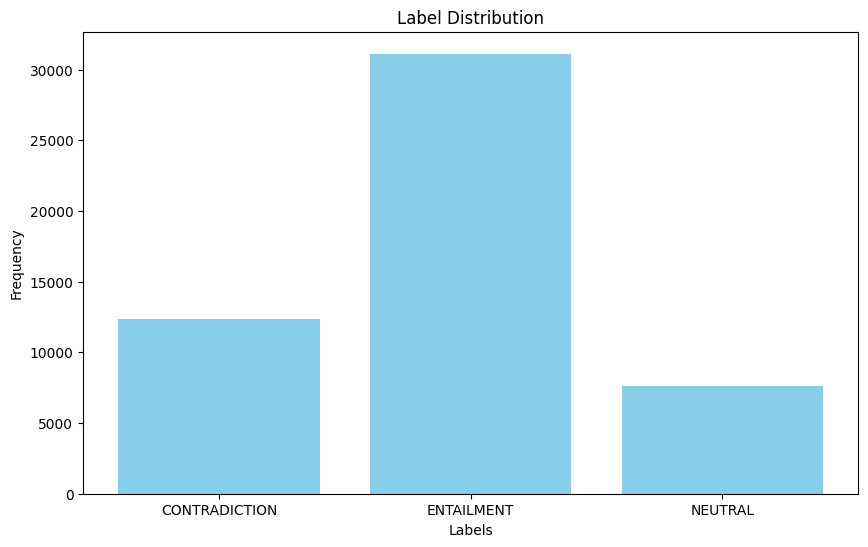

In [9]:
labels = original_data['train']['label']

draw_dist(labels)

##### Test Set

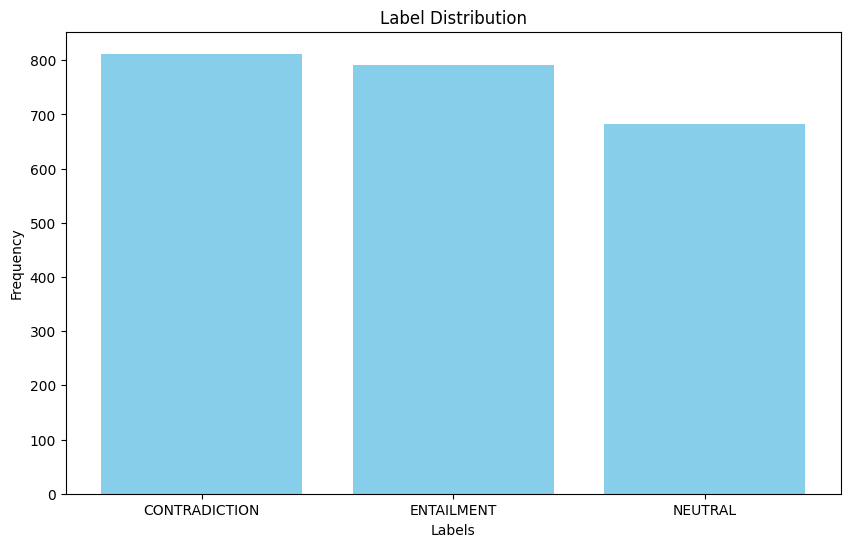

In [10]:
labels = original_data['test']['label']

draw_dist(labels)

### Adversarial Test Set

In [11]:
adversarial_data = load_dataset("iperbole/adversarial_fever_nli")

Generating test split:   0%|          | 0/337 [00:00<?, ? examples/s]

In [12]:
adversarial_data

DatasetDict({
    test: Dataset({
        features: ['part', 'cid', 'premise', 'hypothesis', 'label'],
        num_rows: 337
    })
})

#### Distribution of Data

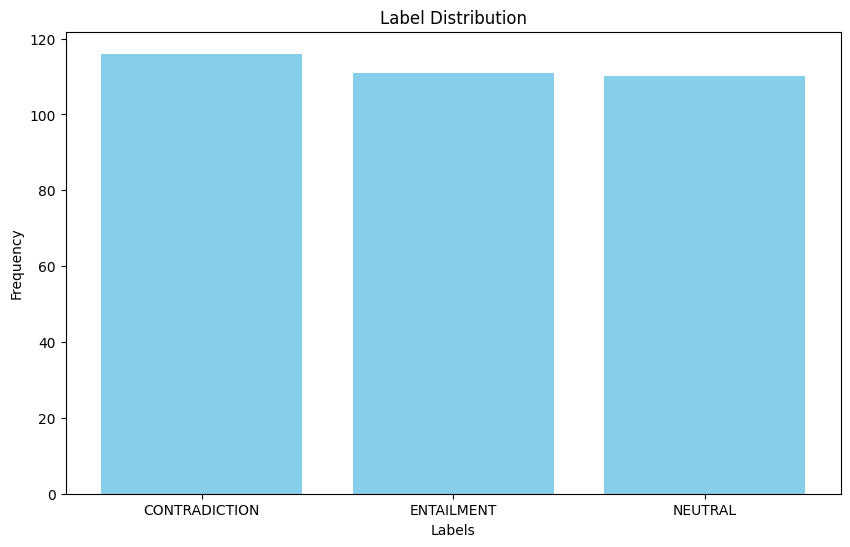

In [13]:
labels = adversarial_data['test']['label']

draw_dist(labels)

## Preparing The Data for Training

### Original Data

In [14]:
clean_original_data = {"train": [], "validation": [], "test": []}

for split in original_data:
    for sample in tqdm(original_data[split]):
        new_sample = sample.copy()
        new_sample['label'] = replace_label(new_sample['label'])
        clean_original_data[split].append(new_sample)
    clean_original_data[split] = Dataset.from_pandas(pd.DataFrame(clean_original_data[split]))
clean_original_data = DatasetDict(clean_original_data)

clean_original_data

100%|██████████| 2287/2287 [00:06<00:00, 339.83it/s]


DatasetDict({
    train: Dataset({
        features: ['id', 'premise', 'hypothesis', 'label', 'wsd', 'srl'],
        num_rows: 51086
    })
    validation: Dataset({
        features: ['id', 'premise', 'hypothesis', 'label', 'wsd', 'srl'],
        num_rows: 2288
    })
    test: Dataset({
        features: ['id', 'premise', 'hypothesis', 'label', 'wsd', 'srl'],
        num_rows: 2287
    })
})

### Adversarial Test Set

In [15]:
clean_adversarial_data = {"test": []}

for split in adversarial_data:
    for sample in tqdm(adversarial_data[split]):
        new_sample = sample.copy()
        new_sample['label'] = replace_label(new_sample['label'])
        clean_adversarial_data[split].append(new_sample)
    clean_adversarial_data[split] = Dataset.from_pandas(pd.DataFrame(clean_adversarial_data[split]))
clean_adversarial_data = DatasetDict(clean_adversarial_data)

clean_adversarial_data

100%|██████████| 337/337 [00:00<00:00, 13572.37it/s]


DatasetDict({
    test: Dataset({
        features: ['part', 'cid', 'premise', 'hypothesis', 'label'],
        num_rows: 337
    })
})

## Training with the Original Data

In [16]:
model = AutoModelForSequenceClassification.from_pretrained(
    language_model_name,
    ignore_mismatched_sizes=True,
    output_attentions=False,
    output_hidden_states=False,
    num_labels=3
)

tokenizer = AutoTokenizer.from_pretrained(language_model_name)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [17]:
def tokenize_function(examples):
    return tokenizer(examples["premise"], examples['hypothesis'], padding=True, truncation=True)

In [18]:
tokenized_original_data = clean_original_data.map(tokenize_function, batched=True)
tokenized_adversarial_data = clean_adversarial_data.map(tokenize_function, batched=True)

Map:   0%|          | 0/51086 [00:00<?, ? examples/s]

Map:   0%|          | 0/2288 [00:00<?, ? examples/s]

Map:   0%|          | 0/2287 [00:00<?, ? examples/s]

Map:   0%|          | 0/337 [00:00<?, ? examples/s]

In [19]:
training_args = TrainingArguments(
    run_name='NLI_ORIGINAL',
    output_dir='./results',
    save_steps=500,  # Save checkpoint every 500 steps
    save_total_limit=1,  # Only keep the last checkpoint
    evaluation_strategy="steps",  # Evaluate during training
    eval_steps=500,  # Evaluate every 500 steps
    logging_dir='./logs',  # Directory for logs
    logging_steps=100,  # Log every 100 steps
    per_device_train_batch_size=batch_size,  # Adjust as per your setup
    per_device_eval_batch_size=batch_size,
    num_train_epochs=epochs,
    load_best_model_at_end=False,  # This is optional based on your need
    warmup_steps=500,
    weight_decay=weight_decay,
)

/opt/conda/lib/python3.10/site-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [20]:
train_dataset = tokenized_original_data["train"].remove_columns(['id', 'premise', 'hypothesis', 'wsd', 'srl'])
eval_dataset1 = tokenized_original_data["test"].remove_columns(['id', 'premise', 'hypothesis', 'wsd', 'srl'])

eval_dataset2 = tokenized_adversarial_data["test"].remove_columns(['part', 'cid', 'premise', 'hypothesis'])

In [21]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset1,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [22]:
trainer.train()

wandb: Currently logged in as: alighasemi. Use `wandb login --relogin` to force relogin
wandb: wandb version 0.17.4 is available!  To upgrade, please run:
wandb:  $ pip install wandb --upgrade
wandb: Tracking run with wandb version 0.17.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20240711_092717-hito1w00
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run NLI_ORIGINAL
wandb: ⭐️ View project at https://wandb.ai/alighasemi/huggingface
wandb: 🚀 View run at https://wandb.ai/alighasemi/huggingface/runs/hito1w00
/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
500,0.480600,0.846463,0.688238,0.684315,0.688238,0.663821
1000,0.425800,0.769544,0.720595,0.717468,0.720595,0.711050
1500,0.376300,0.730877,0.741146,0.736726,0.741146,0.733388


/tmp/ipykernel_24/3378025323.py:2: FutureWarning: load_metric is deprecated and will be removed in the next major version of datasets. Use 'evaluate.load' instead, from the new library 🤗 Evaluate: https://huggingface.co/docs/evaluate
  load_accuracy = load_metric("accuracy")
/opt/conda/lib/python3.10/site-packages/datasets/load.py:759: FutureWarning: The repository for accuracy contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.19.2/metrics/accuracy/accuracy.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metric from the next major release of `datasets`.
  warnings.warn(


/opt/conda/lib/python3.10/site-packages/datasets/load.py:759: FutureWarning: The repository for precision contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.19.2/metrics/precision/precision.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metric from the next major release of `datasets`.
  warnings.warn(


/opt/conda/lib/python3.10/site-packages/datasets/load.py:759: FutureWarning: The repository for recall contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.19.2/metrics/recall/recall.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metric from the next major release of `datasets`.
  warnings.warn(


/opt/conda/lib/python3.10/site-packages/datasets/load.py:759: FutureWarning: The repository for f1 contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.19.2/metrics/f1/f1.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metric from the next major release of `datasets`.
  warnings.warn(


/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '
/opt/conda/lib/python3.10/site-packages/datasets/load.py:759: FutureWarning: The repository for accuracy contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.19.2/metrics/accuracy/accuracy.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metric from the next major release of `datasets`.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/datasets/load.py:759: FutureWarning: The repository for precision contains custom code which must be executed to correctly load the metric. You can inspect 

TrainOutput(global_step=1597, training_loss=0.49118129178443104, metrics={'train_runtime': 2749.6652, 'train_samples_per_second': 18.579, 'train_steps_per_second': 0.581, 'total_flos': 1.3434373774128384e+16, 'train_loss': 0.49118129178443104, 'epoch': 1.0})

In [23]:
trainer.evaluate(eval_dataset=eval_dataset1)

/opt/conda/lib/python3.10/site-packages/datasets/load.py:759: FutureWarning: The repository for accuracy contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.19.2/metrics/accuracy/accuracy.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metric from the next major release of `datasets`.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/datasets/load.py:759: FutureWarning: The repository for precision contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.19.2/metrics/precision/precision.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metr

{'eval_loss': 0.7191369533538818,
 'eval_accuracy': 0.7380848272846524,
 'eval_precision': 0.7340654185586174,
 'eval_recall': 0.7380848272846524,
 'eval_f1': 0.7303098724298293,
 'eval_runtime': 31.0047,
 'eval_samples_per_second': 73.763,
 'eval_steps_per_second': 2.322,
 'epoch': 1.0}

In [24]:
trainer.evaluate(eval_dataset=eval_dataset2)

/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '
/opt/conda/lib/python3.10/site-packages/datasets/load.py:759: FutureWarning: The repository for accuracy contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.19.2/metrics/accuracy/accuracy.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metric from the next major release of `datasets`.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/datasets/load.py:759: FutureWarning: The repository for precision contains custom code which must be executed to correctly load the metric. You can inspect 

{'eval_loss': 1.1933186054229736,
 'eval_accuracy': 0.56973293768546,
 'eval_precision': 0.5716224660120567,
 'eval_recall': 0.56973293768546,
 'eval_f1': 0.5704483545161089,
 'eval_runtime': 5.0275,
 'eval_samples_per_second': 67.032,
 'eval_steps_per_second': 2.188,
 'epoch': 1.0}

## Augmenting the Original Train Set

### Synonym Replacement

In [25]:
def replace_synonym(sample):
    new_sentences = []
    synonyms = []
    
    tokens = sample['wsd']['hypothesis']
    for token in tokens:
        if token['pos'] == 'NOUN' and token['nltkSynset'] != 'O':
            synset = wn.synset(token['nltkSynset'])
            for lemma in synset.lemma_names():
                if lemma != token['lemma']:
                    synonyms.append([lemma, token['index']])
                    
    for synonym in synonyms:
        new_sentence = [tokens[i]['text'] for i in range(synonym[1])]
        new_sentence.append(synonym[0])
        new_sentence.extend([tokens[i]['text'] for i in range(synonym[1] + 1, len(tokens))])
        new_sentence = ' '.join(new_sentence)
        new_sentences.append({
            "premise": sample['premise'],
            "hypothesis": new_sentence,
            "label": sample['label'],
        })
    
    return new_sentences

### Hypernym Replacement

In [26]:
def replace_hypernym(sample):
    new_sentences = []
    hypernyms = []
    
    tokens = sample['wsd']['hypothesis']
    for token in tokens:
        if token['pos'] == 'NOUN' and token['nltkSynset'] != 'O':
            synset = wn.synset(token['nltkSynset'])
            for hypernym in synset.hypernyms():
                hypernyms.append([hypernym.lemma_names()[0], token['index']])
                    
    for hypernym in hypernyms:
        new_sentence = [tokens[i]['text'] for i in range(hypernym[1])]
        new_sentence.append(hypernym[0])
        new_sentence.extend([tokens[i]['text'] for i in range(hypernym[1] + 1, len(tokens))])
        new_sentence = ' '.join(new_sentence)
        new_sentences.append({
            "premise": sample['premise'],
            "hypothesis": new_sentence,
            "label": sample['label'],
        })
    
    return new_sentences

### Antonym Replacement

In [27]:
def replace_antonym(sample):
    new_sentences = []
    antonyms = []
    
    tokens = sample['wsd']['hypothesis']
    for token in tokens:
        if token['pos'] == 'NOUN' and token['nltkSynset'] != 'O':
            synset = wn.synset(token['nltkSynset'])
            for antonym in synset.lemmas()[0].antonyms():
                antonyms.append([antonym.name(), token['index']])
                    
    for antonym in antonyms:
        new_sentence = [tokens[i]['text'] for i in range(antonym[1])]
        new_sentence.append(antonym[0])
        new_sentence.extend([tokens[i]['text'] for i in range(antonym[1] + 1, len(tokens))])
        new_sentence = ' '.join(new_sentence)
        new_sentences.append({
            "premise": sample['premise'],
            "hypothesis": new_sentence,
            "label": 0,
        })
    
    return new_sentences

### Hyponym Replacement

In [28]:
def replace_hyponym(sample):
    new_sentences = []
    hyponyms = []
    
    tokens = sample['wsd']['hypothesis']
    for token in tokens:
        if token['pos'] == 'NOUN' and token['nltkSynset'] != 'O':
            synset = wn.synset(token['nltkSynset'])
            for hyponym in synset.hyponyms():
                hyponyms.append([hyponym.lemma_names()[0], token['index']])
                    
    for hyponym in hyponyms:
        new_sentence = [tokens[i]['text'] for i in range(hyponym[1])]
        new_sentence.append(hyponym[0])
        new_sentence.extend([tokens[i]['text'] for i in range(hyponym[1] + 1, len(tokens))])
        new_sentence = ' '.join(new_sentence)
        new_sentences.append({
            "premise": sample['premise'],
            "hypothesis": new_sentence,
            "label": 1 if sample['label'] == 2 else 0,
        })
    
    return new_sentences

### Swap Agent and Patient

In [29]:
def swap_agent_patient(sample):
    new_sentence = []
    
    tokens = sample['srl']['hypothesis']['tokens']
    annotations = sample['srl']['hypothesis']['annotations']
    
    if len(annotations) > 0:
        roles = annotations[0]['verbatlas']['roles']

        agent = None
        patient = None
        for role in roles:
            if role['role'] == "Agent":
                agent = role['span']
            if role['role'] == "Patient":
                patient = role['span']

        if agent and patient:
            new_sentence.extend([tokens[i]['rawText'] for i in range(agent[0])])
            new_sentence.extend([tokens[i]['rawText'] for i in range(*patient)])
            new_sentence.extend([tokens[i]['rawText'] for i in range(agent[1], patient[0])])
            new_sentence.extend([tokens[i]['rawText'] for i in range(*agent)])
            new_sentence.extend([tokens[i]['rawText'] for i in range(patient[1], len(tokens))])
            new_sentence = " ".join(new_sentence)
            
            return {
                "premise": sample['premise'],
                "hypothesis": new_sentence,
                "label": 0,
            }

### Change Time

In [30]:
def process_year_string(year_str):
    # Check if the input string is exactly 4 characters long
    if len(year_str) != 4:
        return year_str, False
    
    # Check if all characters in the string are digits
    if not year_str.isdigit():
        return year_str, False
    
    # Generate a different random year
    new_year = random.randint(1000, 10000)
    while new_year == int(year_str):
        new_year = random.randint(1000, 10000)
    
    return str(new_year), True

In [31]:
def change_time(sample):
    new_sentence = []
    
    tokens = sample['srl']['hypothesis']['tokens']
    annotations = sample['srl']['hypothesis']['annotations']
    
    if len(annotations) > 0:
        roles = annotations[0]['verbatlas']['roles']

        time = None
        for role in roles:
            if role['role'] == "Time":
                time = role['span']
                
        if time:
            new_sentence.extend([tokens[i]['rawText'] for i in range(time[0])])
            changed = False
            for i in range(*time):
                new_token, year_changed = process_year_string(tokens[i]['rawText'])
                new_sentence.append(new_token)
                if year_changed:
                    changed = True
            new_sentence.extend([tokens[i]['rawText'] for i in range(time[1], len(tokens))])
            new_sentence = " ".join(new_sentence)
            
            if changed:
                return {
                    "premise": sample['premise'],
                    "hypothesis": new_sentence,
                    "label": 0,
                }

### Convert Numbers to Characters

In [32]:
def process_num_string(num_str):
    # Check if all characters in the string are digits
    if not num_str.isdigit():
        return num_str, False
    
    # Convert number to its equivalent character value
    num = int(num_str)
    num_text = num2words(num).replace("-", " ")
    
    return str(num_text), True

In [33]:
def convert_nums_to_chars(sample):
    new_sentence = []
    
    tokens = sample['srl']['hypothesis']['tokens']

    changed = False
    for token in tokens:
        new_token, num_changed = process_num_string(token['rawText'])
        new_sentence.append(new_token)
        if num_changed:
            changed = True
    new_sentence = " ".join(new_sentence)

    if changed:
        return {
            "premise": sample['premise'],
            "hypothesis": new_sentence,
            "label": sample['label'],
        }

In [34]:
train_set = clean_original_data['train']

augmented_synonyms = []
augmented_hypernyms = []
augmented_antonyms = []
augmented_hyponyms = []
augmented_agent_patient = []
augmented_time = []
augmented_nums_chars = []
for sample in tqdm(train_set):
    # WSD Augmentations
    augmented_synonyms.extend(replace_synonym(sample)) # Synonym Replacement
    augmented_hypernyms.extend(replace_hypernym(sample)) # Hypernym Replacement
    if sample['label'] == 2:
        augmented_antonyms.extend(replace_antonym(sample)) # Antonym Replacement
    if sample['label'] == 0 or sample['label'] == 2:
        augmented_hyponyms.extend(replace_hyponym(sample)) # Hyponym Replacement
        
    # SRL Augmentations
    if sample['label'] == 2:
        new_sample = swap_agent_patient(sample) # Agent/Patient Swap
        if new_sample:
            augmented_agent_patient.append(new_sample)
            
        new_sample = change_time(sample) # Change Year
        if new_sample:
            augmented_time.append(new_sample)

    # General Augmentations
    new_sample = convert_nums_to_chars(sample) # Convert Number Digits to Characters
    if new_sample:
        augmented_nums_chars.append(new_sample)

100%|██████████| 51086/51086 [02:51<00:00, 298.10it/s]


In [35]:
augmented_synonyms = Dataset.from_pandas(pd.DataFrame(augmented_synonyms))
augmented_hypernyms = Dataset.from_pandas(pd.DataFrame(augmented_hypernyms))
augmented_antonyms = Dataset.from_pandas(pd.DataFrame(augmented_antonyms))
augmented_hyponyms = Dataset.from_pandas(pd.DataFrame(augmented_hyponyms))
augmented_agent_patient = Dataset.from_pandas(pd.DataFrame(augmented_agent_patient))
augmented_time = Dataset.from_pandas(pd.DataFrame(augmented_time))
augmented_nums_chars = Dataset.from_pandas(pd.DataFrame(augmented_nums_chars))

### Analyzing the Augmented Techniques

In [36]:
augmented_synonyms

Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 143231
})

In [37]:
augmented_hypernyms

Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 73658
})

In [38]:
augmented_antonyms

Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 2013
})

In [39]:
augmented_hyponyms

Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 1230132
})

In [40]:
augmented_agent_patient

Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 1018
})

In [41]:
augmented_time

Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 1467
})

In [42]:
augmented_nums_chars

Dataset({
    features: ['premise', 'hypothesis', 'label'],
    num_rows: 6830
})

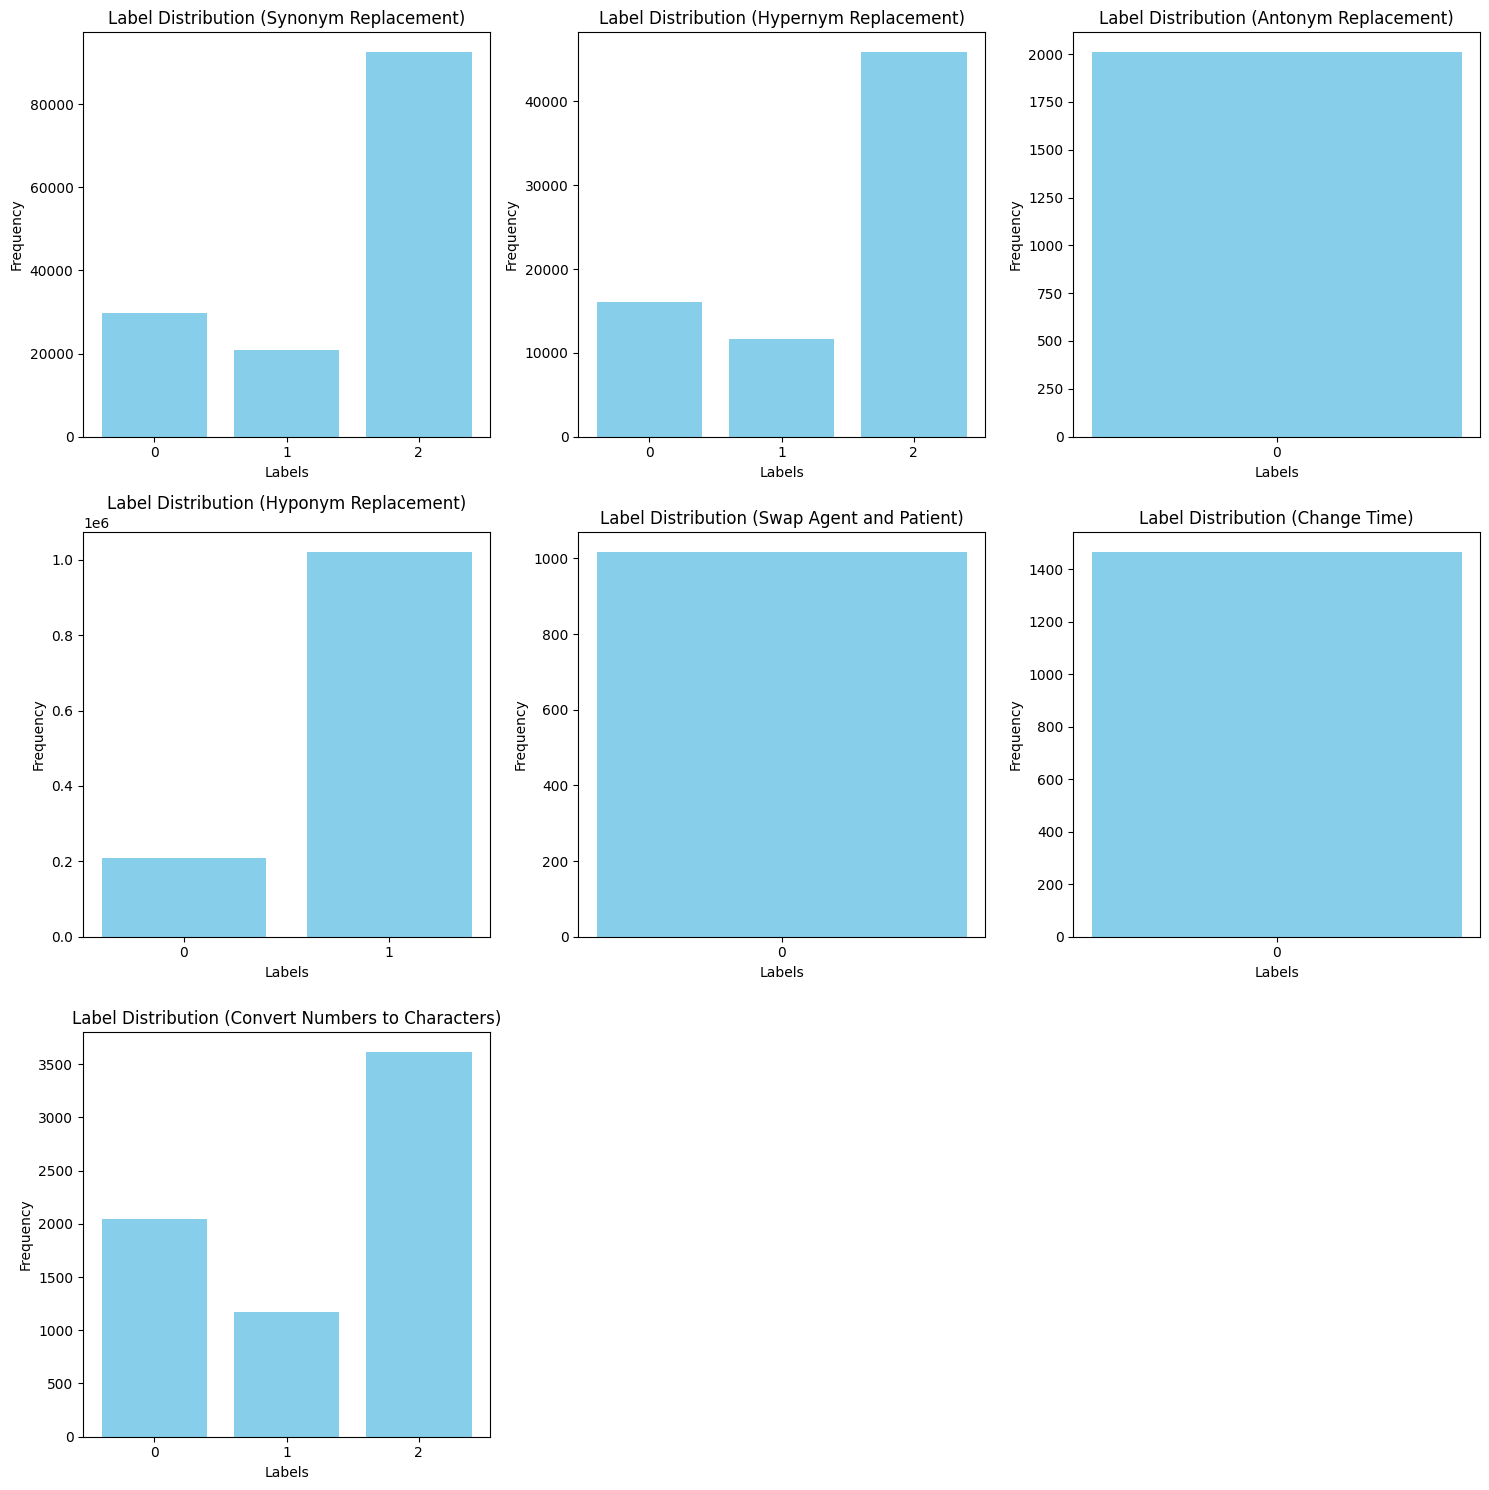

In [43]:
data_list = [
    (augmented_synonyms['label'], "Synonym Replacement"),
    (augmented_hypernyms['label'], "Hypernym Replacement"),
    (augmented_antonyms['label'], "Antonym Replacement"),
    (augmented_hyponyms['label'], "Hyponym Replacement"),
    (augmented_agent_patient['label'], "Swap Agent and Patient"),
    (augmented_time['label'], "Change Time"),
    (augmented_nums_chars['label'], "Convert Numbers to Characters")
]

fig, axs = plt.subplots(3, 3, figsize=(15, 15))  # Create a figure with a 3x3 grid of subplots
axs = axs.flatten()  # Flatten the 3x3 array of axes to make it easier to iterate over
for i, data in enumerate(data_list):
    label_counts = Counter(data[0])
    sorted_label_counts = sorted(label_counts.items())
    labels, counts = zip(*sorted_label_counts)

    axs[i].bar(labels, counts, color='skyblue')
    axs[i].set_title(f'Label Distribution ({data[1]})')
    axs[i].set_xlabel('Labels')
    axs[i].set_ylabel('Frequency')
    axs[i].set_xticks(labels)
    axs[i].set_xticklabels(labels, rotation=0)
for j in range(len(data_list), 9):
    fig.delaxes(axs[j])  # Remove the unused subplots
plt.tight_layout()
plt.show()

### Mixing the Different Augmented Techniques

In [44]:
desired_size = len(train_set)

augmented_train_data = concatenate_datasets([
    augmented_antonyms, augmented_agent_patient, augmented_time, augmented_nums_chars
])

remaining_items = desired_size - len(augmented_train_data)
shuffled_augmented_hyponyms = augmented_hyponyms.shuffle(seed=42)
sampled_augmented_hyponyms = shuffled_augmented_hyponyms.select(range(int(0.5 * remaining_items)))
augmented_train_data = concatenate_datasets([augmented_train_data, sampled_augmented_hyponyms])

remaining_items = desired_size - len(augmented_train_data)
shuffled_augmented_synonyms = augmented_synonyms.shuffle(seed=42)
sampled_augmented_synonyms = shuffled_augmented_synonyms.select(range(int(0.5 * remaining_items)))
augmented_train_data = concatenate_datasets([augmented_train_data, sampled_augmented_synonyms])

remaining_items = desired_size - len(augmented_train_data)
shuffled_augmented_hypernyms = augmented_hypernyms.shuffle(seed=42)
sampled_augmented_hypernyms = shuffled_augmented_hypernyms.select(range(remaining_items))
augmented_train_data = concatenate_datasets([augmented_train_data, sampled_augmented_hypernyms])

augmented_train_data = concatenate_datasets([
    augmented_train_data, clean_original_data["train"].remove_columns(['id', 'wsd', 'srl']),
])

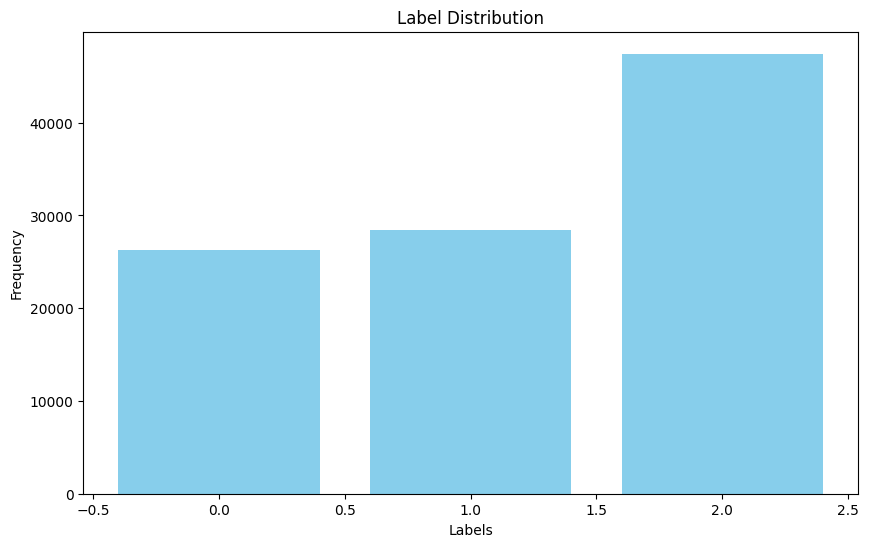

In [45]:
draw_dist(augmented_train_data['label'])

In [46]:
augmented_data = {
    "train": augmented_train_data,
    "validation": clean_original_data["validation"].remove_columns(['id', 'wsd', 'srl']),
    "test": clean_original_data["test"].remove_columns(['id', 'wsd', 'srl']),
}

augmented_data = DatasetDict(augmented_data)
augmented_data

DatasetDict({
    train: Dataset({
        features: ['premise', 'hypothesis', 'label'],
        num_rows: 102172
    })
    validation: Dataset({
        features: ['premise', 'hypothesis', 'label'],
        num_rows: 2288
    })
    test: Dataset({
        features: ['premise', 'hypothesis', 'label'],
        num_rows: 2287
    })
})

## Training with the Adversarial Data

In [47]:
model = AutoModelForSequenceClassification.from_pretrained(
    language_model_name,
    ignore_mismatched_sizes=True,
    output_attentions=False,
    output_hidden_states=False,
    num_labels=3
)

tokenizer = AutoTokenizer.from_pretrained(language_model_name)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [48]:
def tokenize_function(examples):
    return tokenizer(examples["premise"], examples['hypothesis'], padding=True, truncation=True)

In [49]:
tokenized_augmented_data = augmented_data.map(tokenize_function, batched=True)
tokenized_adversarial_data = clean_adversarial_data.map(tokenize_function, batched=True)

Map:   0%|          | 0/102172 [00:00<?, ? examples/s]

Map:   0%|          | 0/2288 [00:00<?, ? examples/s]

Map:   0%|          | 0/2287 [00:00<?, ? examples/s]

Map:   0%|          | 0/337 [00:00<?, ? examples/s]

In [50]:
training_args = TrainingArguments(
    run_name='NLI_ORIGINAL',
    output_dir='./results',
    save_steps=500,  # Save checkpoint every 500 steps
    save_total_limit=1,  # Only keep the last checkpoint
    evaluation_strategy="steps",  # Evaluate during training
    eval_steps=500,  # Evaluate every 500 steps
    logging_dir='./logs',  # Directory for logs
    logging_steps=100,  # Log every 100 steps
    per_device_train_batch_size=batch_size,  # Adjust as per your setup
    per_device_eval_batch_size=batch_size,
    num_train_epochs=epochs,
    load_best_model_at_end=False,  # This is optional based on your need
    warmup_steps=500,
    weight_decay=weight_decay,
)

/opt/conda/lib/python3.10/site-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [51]:
train_dataset = tokenized_augmented_data["train"].remove_columns(['premise', 'hypothesis'])
eval_dataset1 = tokenized_augmented_data["test"].remove_columns(['premise', 'hypothesis'])

eval_dataset2 = tokenized_adversarial_data["test"].remove_columns(['part', 'cid', 'premise', 'hypothesis'])

In [52]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset1,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [53]:
trainer.train()

/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
500,0.602800,0.945229,0.675557,0.678129,0.675557,0.666004
1000,0.470100,0.975164,0.679930,0.690497,0.679930,0.650888
1500,0.449000,0.795966,0.712287,0.709027,0.712287,0.702013
2000,0.412900,0.778307,0.722344,0.717493,0.722344,0.708360
2500,0.403700,0.758317,0.724530,0.723269,0.724530,0.713407
3000,0.348100,0.754400,0.742457,0.738867,0.742457,0.735644


/opt/conda/lib/python3.10/site-packages/datasets/load.py:759: FutureWarning: The repository for accuracy contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.19.2/metrics/accuracy/accuracy.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metric from the next major release of `datasets`.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/datasets/load.py:759: FutureWarning: The repository for precision contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.19.2/metrics/precision/precision.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metr

TrainOutput(global_step=3193, training_loss=0.4908147866248786, metrics={'train_runtime': 5484.2095, 'train_samples_per_second': 18.63, 'train_steps_per_second': 0.582, 'total_flos': 2.6860212806769216e+16, 'train_loss': 0.4908147866248786, 'epoch': 1.0})

In [54]:
trainer.evaluate(eval_dataset=eval_dataset1)

/opt/conda/lib/python3.10/site-packages/datasets/load.py:759: FutureWarning: The repository for accuracy contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.19.2/metrics/accuracy/accuracy.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metric from the next major release of `datasets`.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/datasets/load.py:759: FutureWarning: The repository for precision contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.19.2/metrics/precision/precision.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metr

{'eval_loss': 0.7812879085540771,
 'eval_accuracy': 0.7354613030170529,
 'eval_precision': 0.7326811674792321,
 'eval_recall': 0.7354613030170529,
 'eval_f1': 0.7272018621088556,
 'eval_runtime': 31.1334,
 'eval_samples_per_second': 73.458,
 'eval_steps_per_second': 2.313,
 'epoch': 1.0}

In [55]:
trainer.evaluate(eval_dataset=eval_dataset2)

/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '
/opt/conda/lib/python3.10/site-packages/datasets/load.py:759: FutureWarning: The repository for accuracy contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.19.2/metrics/accuracy/accuracy.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metric from the next major release of `datasets`.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/datasets/load.py:759: FutureWarning: The repository for precision contains custom code which must be executed to correctly load the metric. You can inspect 

{'eval_loss': 1.2336710691452026,
 'eval_accuracy': 0.5905044510385756,
 'eval_precision': 0.5917341177737951,
 'eval_recall': 0.5905044510385756,
 'eval_f1': 0.5902273197423707,
 'eval_runtime': 4.9833,
 'eval_samples_per_second': 67.626,
 'eval_steps_per_second': 2.207,
 'epoch': 1.0}